In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, wilcoxon
from scipy.optimize import linear_sum_assignment
from statsmodels.stats.multitest import multipletests

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

In [3]:
processed_dir = Path(dir_config.data.processed)
shared_dir    = processed_dir / "shared_glm_hmm"

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md  = session_metadata(metadata).set_index("session_id")

SELECTED = "XY__tgt"
bundle   = pickle.load(open(shared_dir / SELECTED / "all_subjects_final.pkl", "rb"))
pooled   = bundle["model"]["pooled"]
feats    = bundle["config"]["model_features"]
K        = bundle["best_k"]
data     = bundle["data"]

# S2: highest stimulus sensitivity — the "engaged" state
PRIMARY_STATE = 2

STATE_COLORS = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3"]
print(f"Model: {SELECTED}  K={K}  features: {feats}")

Model: XY__tgt  K=4  features: ['stimulus', 'color', 'bias', 'prev_choice_1', 'prev_target_1', 'prev_choice_target_1']


## Build per-session metrics

For each session we extract:
- **Occupancy** from the *shared pooled model* (identical basis for every session)
- **GLM weights** from the per-session fit, aligned to the pooled basis via Hungarian assignment

This gives 4 metrics × 4 states per session:
`occ`, `w_stimulus`, `w_color`, `w_bias`

In [4]:
def _align(w, ref):
    """Hungarian alignment of per-session weight matrix (K,M) to pooled reference."""
    cost = np.array([[np.sum((w[i] - ref[j])**2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col)
    inv[col] = np.arange(len(col))
    return inv


ref_w = -pooled.observations.params[:, 0, :]   # (K, M)

WEIGHT_FEATS = ["stimulus", "color", "bias"]    # the 3 GLM weights we report
WEIGHT_IDX   = {f: feats.index(f) for f in WEIGHT_FEATS if f in feats}

rows = []
for sid, df in data.items():
    if sid not in sess_md.index:
        continue
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    valid = msk[:, 0]

    # Occupancy under the shared pooled model
    post = pooled.expected_states(data=obs, input=inp, mask=msk)[0]   # (T, K)
    occ  = post[valid].mean(0)                                         # (K,)

    # Per-session weights aligned to pooled basis
    m = bundle["model"]["models"][sid]
    w = -m.observations.params[:, 0, :]    # (K, M)
    perm = _align(w, ref_w)
    w_al = w[perm]                          # (K, M)

    row = {"session_id": sid}
    for k in range(K):
        row[f"occ_S{k}"] = occ[k]
        for fname, fi in WEIGHT_IDX.items():
            row[f"w_{fname}_S{k}"] = w_al[k, fi]
    rows.append(row)

sess_df = pd.DataFrame(rows).set_index("session_id")
sess_df = sess_df.join(sess_md[["subject_id", "subtype", "medication", "is_pd"]])
print("Per-session metrics table:", sess_df.shape)
sess_df.head(3)

Per-session metrics table: (100, 20)


,occ_S0,w_stimulus_S0,w_color_S0,w_bias_S0,occ_S1,w_stimulus_S1,w_color_S1,w_bias_S1,occ_S2,w_stimulus_S2,w_color_S2,w_bias_S2,occ_S3,w_stimulus_S3,w_color_S3,w_bias_S3,subject_id,subtype,medication,is_pd
session_id,,,,,,,,,,,,,,,,,,,,
ALE_OFF,0.743750,1.362507,0.242035,0.842798,0.018726,4.443998,-0.964383,0.092423,0.235352,4.701364,0.315571,1.843770,0.002172,-0.545364,1.024548,-0.098908,ALE,NaN,off,1
ALE_ON,0.135109,1.228905,-0.370518,1.144047,0.008009,1.182004,0.520801,0.241643,0.003613,3.159703,-0.659170,2.522621,0.853269,0.135447,0.314157,0.379476,ALE,NaN,on,1
AV,0.527742,3.974914,-0.445954,0.096872,0.232426,3.532778,0.749979,-1.324031,0.239075,5.162080,0.232680,0.222727,0.000756,-0.299621,0.206428,0.957758,AV,HC,none,0


In [5]:
# Average sessions within each subject × medication combination
metric_cols = [c for c in sess_df.columns if c.startswith(("occ_", "w_"))]
subj_df = (
    sess_df
    .groupby(["subject_id", "subtype", "medication", "is_pd"])[metric_cols]
    .mean()
    .reset_index()
)
subj_df["subtype"] = pd.Categorical(subj_df["subtype"], ["HC", "tremor", "bradykinetic", "intermediate"])
print("Per-subject metrics table:", subj_df.shape)

# Convenience subsets
hc     = subj_df[subj_df["subtype"] == "HC"]
pd_off = subj_df[(subj_df["is_pd"] == 1) & (subj_df["medication"] == "off")]
pd_on  = subj_df[(subj_df["is_pd"] == 1) & (subj_df["medication"] == "on")]
print(f"  HC n={len(hc)}  PD-OFF n={len(pd_off)}  PD-ON n={len(pd_on)}")

Per-subject metrics table: (62, 20)
  HC n=18  PD-OFF n=22  PD-ON n=22


## S2 comparisons — 4 contrasts

Each contrast tests all 4 S2 metrics (occ, stimulus, color, bias) with BH-FDR correction
applied within the contrast across those 4 metrics.

| # | Contrast | Test |
|---|---|---|
| 1 | HC vs PD-OFF (all) | Mann-Whitney U (independent) |
| 2 | Tremor-OFF vs Brady-OFF | Mann-Whitney U (independent) |
| 3 | Tremor-OFF vs Tremor-ON | Wilcoxon signed-rank (paired) |
| 4 | Brady-OFF vs Brady-ON | Wilcoxon signed-rank (paired) |

In [6]:
METRICS       = ["occ"] + [f"w_{f}" for f in ["stimulus", "color", "bias"]]
METRIC_LABELS = {"occ": "Occupancy", "w_stimulus": "Stimulus weight",
                 "w_color": "Color (prior) weight", "w_bias": "Bias weight"}

def col(metric, k):
    return f"{metric}_S{k}"

P = PRIMARY_STATE   # shorthand


def between(ga, gb, label_a, label_b):
    """Mann-Whitney U, independent groups, FDR across metrics."""
    rows = []
    for m in METRICS:
        c = col(m, P)
        a, b = ga[c].dropna().values, gb[c].dropna().values
        _, pval = mannwhitneyu(a, b, alternative="two-sided")
        rows.append({"metric": m, "n_a": len(a), "n_b": len(b),
                     f"mean_{label_a}": a.mean(), f"mean_{label_b}": b.mean(),
                     "delta": b.mean() - a.mean(), "p": pval})
    df = pd.DataFrame(rows).set_index("metric")
    _, df["p_fdr"], _, _ = multipletests(df["p"].values, method="fdr_bh")
    df["sig"] = df["p_fdr"] < 0.05
    return df, label_a, label_b


def within(subtype_str, label_a="OFF", label_b="ON"):
    """Paired Wilcoxon, one subtype, OFF vs ON, FDR across metrics."""
    sub = subj_df[(subj_df["is_pd"] == 1) & (subj_df["subtype"] == subtype_str)]
    paired = (
        sub.pivot_table(index="subject_id", columns="medication",
                        values=[col(m, P) for m in METRICS], observed=True)
        .dropna()
    )
    rows = []
    for m in METRICS:
        c = col(m, P)
        a, b = paired[(c, "off")].values, paired[(c, "on")].values
        _, pval = wilcoxon(a, b) if len(a) >= 3 else (np.nan, np.nan)
        rows.append({"metric": m, "n": len(a),
                     f"mean_{label_a}": a.mean(), f"mean_{label_b}": b.mean(),
                     "delta": b.mean() - a.mean(), "p": pval})
    df = pd.DataFrame(rows).set_index("metric")
    valid = df["p"].notna()
    reject, p_fdr, _, _ = multipletests(df.loc[valid, "p"].values, method="fdr_bh")
    df["p_fdr"] = np.nan
    df.loc[valid, "p_fdr"] = p_fdr
    df["sig"] = df["p_fdr"] < 0.05
    return df, label_a, label_b


# convenience subsets (used by all contrasts)
tremor_off  = subj_df[(subj_df["subtype"] == "tremor")      & (subj_df["medication"] == "off")]
tremor_on   = subj_df[(subj_df["subtype"] == "tremor")      & (subj_df["medication"] == "on")]
brady_off   = subj_df[(subj_df["subtype"] == "bradykinetic") & (subj_df["medication"] == "off")]
brady_on    = subj_df[(subj_df["subtype"] == "bradykinetic") & (subj_df["medication"] == "on")]

print(f"Group sizes — HC:{len(hc)}  PD-OFF:{len(pd_off)}  "
      f"Tremor-OFF:{len(tremor_off)}  Tremor-ON:{len(tremor_on)}  "
      f"Brady-OFF:{len(brady_off)}  Brady-ON:{len(brady_on)}")

Group sizes — HC:18  PD-OFF:22  Tremor-OFF:11  Tremor-ON:11  Brady-OFF:10  Brady-ON:10


### Contrast 1 — HC vs PD-OFF (all PD, independent)

In [7]:
c1, la1, lb1 = between(hc, pd_off, "HC", "PD_OFF")
print(f"S{P}: HC vs PD-OFF (Mann-Whitney U, BH-FDR)")
c1[["n_a", "n_b", "mean_HC", "mean_PD_OFF", "delta", "p", "p_fdr", "sig"]].round(4)

S2: HC vs PD-OFF (Mann-Whitney U, BH-FDR)


,n_a,n_b,mean_HC,mean_PD_OFF,delta,p,p_fdr,sig
metric,,,,,,,,
occ,18,22,0.3123,0.2893,-0.0231,0.5054,0.6735,False
w_stimulus,18,22,5.1983,5.0505,-0.1478,0.3483,0.6735,False
w_color,18,22,0.6026,0.1195,-0.4831,0.2479,0.6735,False
w_bias,18,22,0.0197,-0.0512,-0.0709,0.6735,0.6735,False


### Contrast 2 — Tremor-OFF vs Brady-OFF (between subtypes at baseline)

In [8]:
c2, la2, lb2 = between(tremor_off, brady_off, "Tremor_OFF", "Brady_OFF")
print(f"S{P}: Tremor-OFF vs Brady-OFF (Mann-Whitney U, BH-FDR)")
c2[["n_a", "n_b", "mean_Tremor_OFF", "mean_Brady_OFF", "delta", "p", "p_fdr", "sig"]].round(4)

S2: Tremor-OFF vs Brady-OFF (Mann-Whitney U, BH-FDR)


,n_a,n_b,mean_Tremor_OFF,mean_Brady_OFF,delta,p,p_fdr,sig
metric,,,,,,,,
occ,11,10,0.3915,0.1380,-0.2535,0.8053,1.0,False
w_stimulus,11,10,5.6829,4.2709,-1.4120,0.5035,1.0,False
w_color,11,10,0.0965,0.0203,-0.0762,1.0000,1.0,False
w_bias,11,10,-0.0491,-0.0553,-0.0063,0.9159,1.0,False


### Contrast 4 — Bradykinetic: OFF vs ON (paired within-subject)

### Contrast 3 — Tremor: OFF vs ON (paired within-subject)

In [9]:
c3, la3, lb3 = within("tremor")
print(f"S{P}: Tremor OFF→ON (Wilcoxon signed-rank, BH-FDR)")
c3[["n", "mean_OFF", "mean_ON", "delta", "p", "p_fdr", "sig"]].round(4)

S2: Tremor OFF→ON (Wilcoxon signed-rank, BH-FDR)


,n,mean_OFF,mean_ON,delta,p,p_fdr,sig
metric,,,,,,,
occ,11,0.3915,0.2883,-0.1032,0.8311,0.8311,False
w_stimulus,11,5.6829,5.1268,-0.5561,0.3203,0.4271,False
w_color,11,0.0965,0.6259,0.5294,0.2783,0.4271,False
w_bias,11,-0.0491,-0.3560,-0.3069,0.3203,0.4271,False


In [10]:
c4, la4, lb4 = within("bradykinetic")
print(f"S{P}: Brady OFF→ON (Wilcoxon signed-rank, BH-FDR)")
c4[["n", "mean_OFF", "mean_ON", "delta", "p", "p_fdr", "sig"]].round(4)

S2: Brady OFF→ON (Wilcoxon signed-rank, BH-FDR)


,n,mean_OFF,mean_ON,delta,p,p_fdr,sig
metric,,,,,,,
occ,10,0.1380,0.1943,0.0563,0.3223,1.0,False
w_stimulus,10,4.2709,4.3021,0.0311,1.0000,1.0,False
w_color,10,0.0203,0.0621,0.0418,0.9219,1.0,False
w_bias,10,-0.0553,-0.0535,0.0018,0.9219,1.0,False


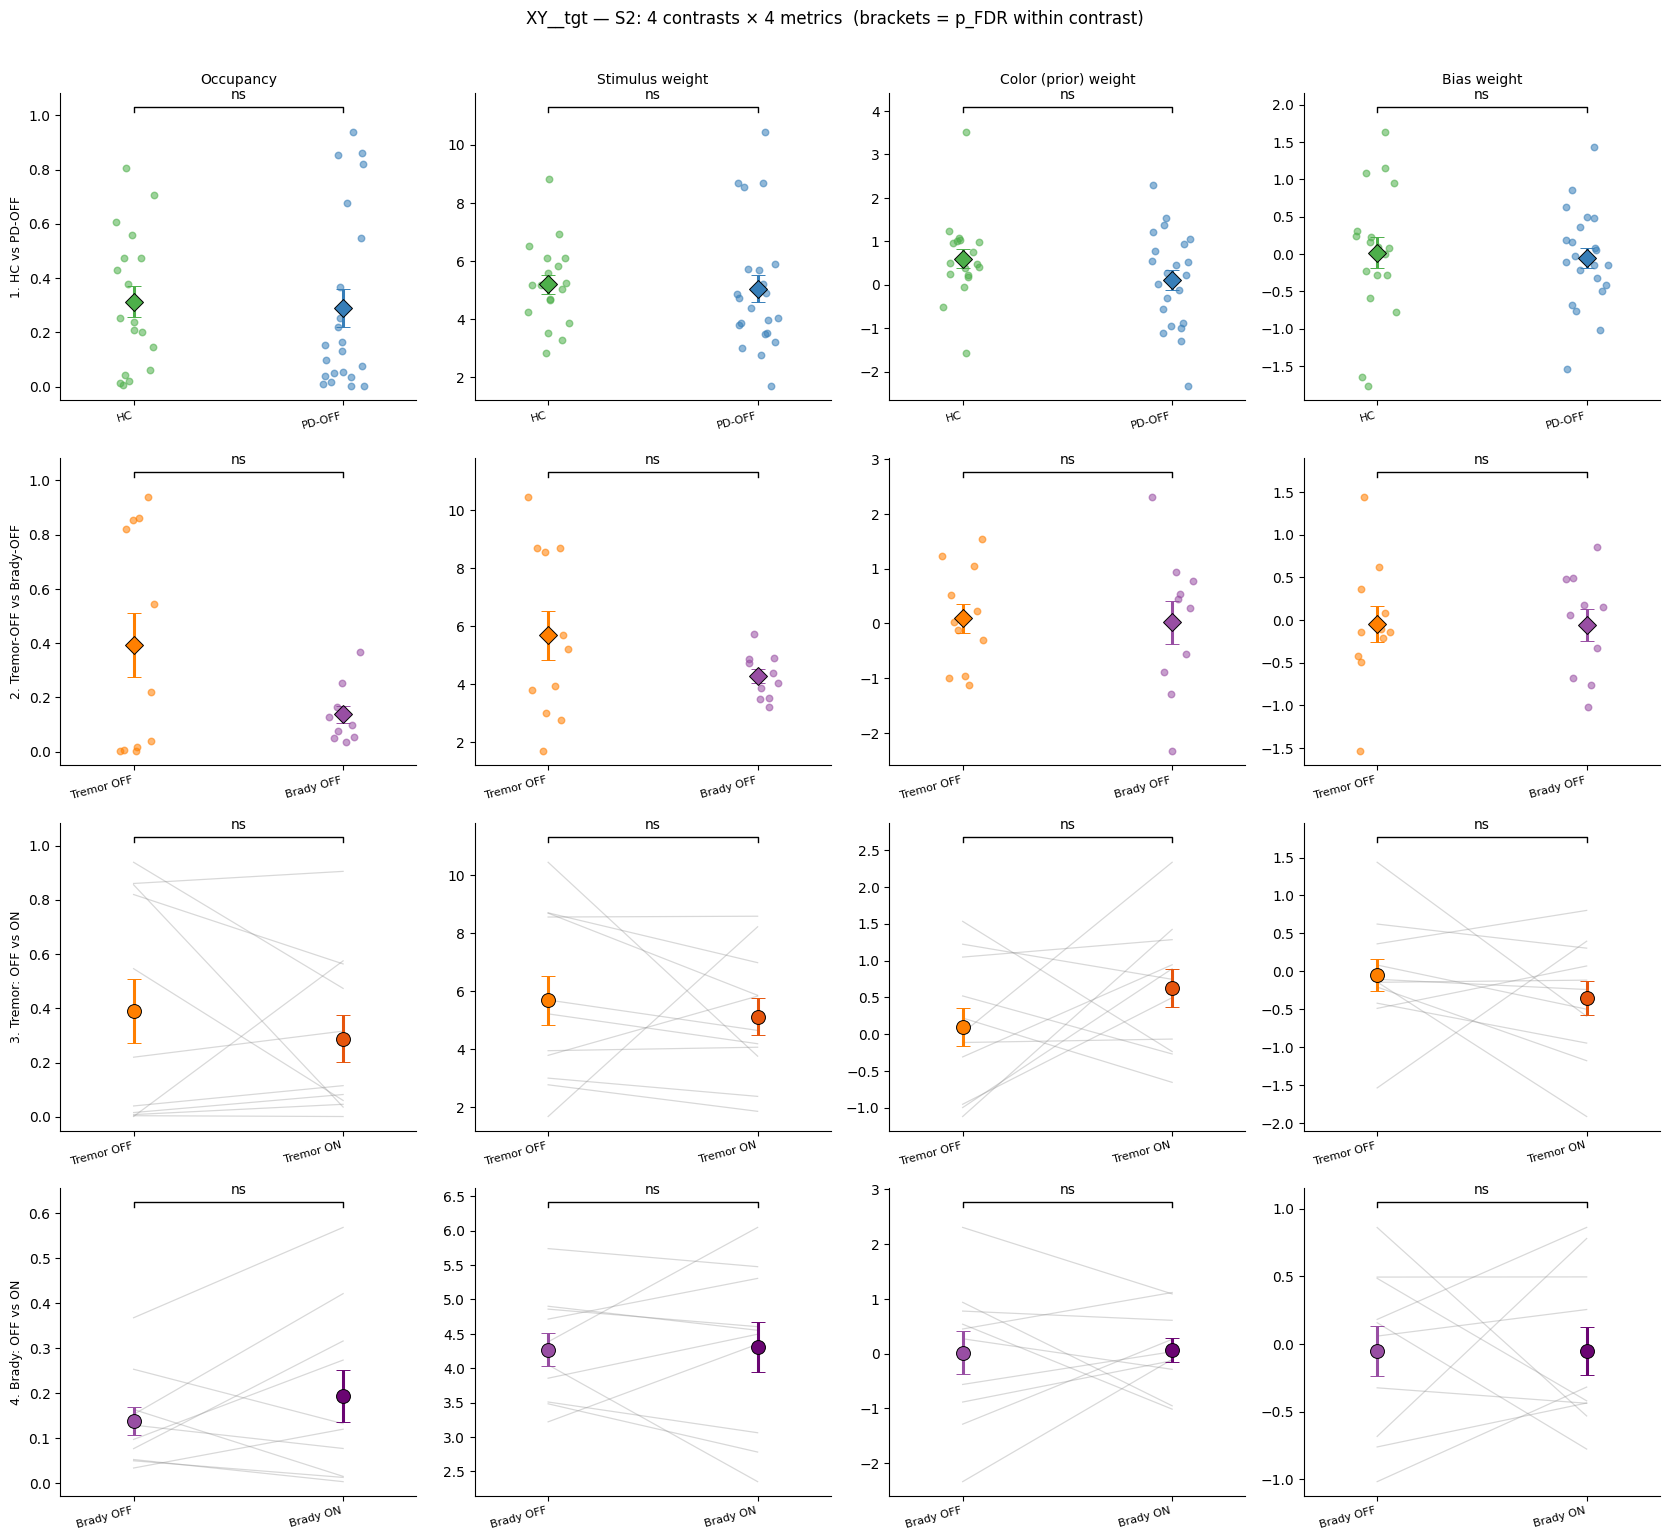

In [11]:
## Summary figure — all 4 contrasts × 4 S2 metrics

CONTRAST_SPEC = [
    # (result_df, group_A_data, group_B_data, label_a, label_b, color_a, color_b, test_type)
    (c1, hc,          pd_off,     "HC",          "PD-OFF",    "#4daf4a", "#377eb8", "between"),
    (c2, tremor_off,  brady_off,  "Tremor OFF",  "Brady OFF", "#ff7f00", "#984ea3", "between"),
    (c3, tremor_off,  tremor_on,  "Tremor OFF",  "Tremor ON", "#ff7f00", "#e6550d", "within_tremor"),
    (c4, brady_off,   brady_on,   "Brady OFF",   "Brady ON",  "#984ea3", "#6a0572", "within_brady"),
]
CONTRAST_TITLES = [
    "1. HC vs PD-OFF",
    "2. Tremor-OFF vs Brady-OFF",
    "3. Tremor: OFF vs ON",
    "4. Brady: OFF vs ON",
]

# paired data for within-subject contrasts
def get_paired(subtype_str):
    sub = subj_df[(subj_df["is_pd"] == 1) & (subj_df["subtype"] == subtype_str)]
    return sub.pivot_table(index="subject_id", columns="medication",
                           values=[col(m, P) for m in METRICS], observed=True).dropna()

paired_tremor = get_paired("tremor")
paired_brady  = get_paired("bradykinetic")

def sig_label(p):
    if pd.isna(p):   return ""
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return "ns"

nC, nM = len(CONTRAST_SPEC), len(METRICS)
fig, axes = plt.subplots(nC, nM, figsize=(4.2 * nM, 3.8 * nC), squeeze=False)

for ri, (res_df, ga, gb, la, lb, ca, cb, ttype) in enumerate(CONTRAST_SPEC):
    for ci, metric in enumerate(METRICS):
        ax = axes[ri][ci]
        c  = col(metric, P)

        if ttype == "between":
            a_vals = ga[c].dropna().values
            b_vals = gb[c].dropna().values
            for xpos, vals, color in [(0, a_vals, ca), (1, b_vals, cb)]:
                jit = np.random.uniform(-0.1, 0.1, len(vals))
                ax.scatter(xpos + jit, vals, color=color, s=22, alpha=0.55, zorder=3)
                ax.errorbar(xpos, vals.mean(), yerr=vals.std()/np.sqrt(len(vals)),
                            color=color, marker="D", ms=9, mec="k", mew=0.7,
                            capsize=5, lw=2.2, zorder=5)
        else:
            paired = paired_tremor if ttype == "within_tremor" else paired_brady
            a_vals = paired[(c, "off")].values
            b_vals = paired[(c, "on")].values
            for o, n in zip(a_vals, b_vals):
                ax.plot([0, 1], [o, n], "-", color="gray", alpha=0.3, lw=0.9)
            for xpos, vals, color in [(0, a_vals, ca), (1, b_vals, cb)]:
                ax.errorbar(xpos, vals.mean(), yerr=vals.std()/np.sqrt(len(vals)),
                            color=color, marker="o", ms=10, mec="k", mew=0.7,
                            capsize=5, lw=2.2, zorder=5)

        # significance label from FDR-corrected p
        p_fdr = res_df.loc[metric, "p_fdr"] if metric in res_df.index else np.nan
        slabel = sig_label(p_fdr)
        yall  = np.concatenate([a_vals, b_vals])
        ymax, ymin = yall.max(), yall.min()
        yrange = ymax - ymin if ymax != ymin else 1
        ytop = ymax + 0.08 * yrange
        ax.plot([0, 0, 1, 1], [ytop, ytop + 0.02*yrange, ytop + 0.02*yrange, ytop],
                lw=1, color="k")
        ax.text(0.5, ytop + 0.04*yrange, slabel, ha="center", va="bottom", fontsize=10)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([la, lb], fontsize=8, rotation=15, ha="right")
        ax.set_xlim(-0.35, 1.35)
        ax.spines[["top", "right"]].set_visible(False)
        if ci == 0:
            ax.set_ylabel(CONTRAST_TITLES[ri], fontsize=9)
        if ri == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=10)

fig.suptitle(f"{SELECTED} — S{P}: 4 contrasts × 4 metrics  (brackets = p_FDR within contrast)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()